# Vis-Head Scores vs. Causal Pointing-Game Accuracy, Across Prompt Phrasing

Two measurements, side by side, for the **same four prompt phrasings** on the
ImageNet-grid dataset:

1. **Vis-Head (Visual Routing Head) scores** — the observational attention-based
   selectivity score (`vir_score` in the original codebase): mean raw attention a
   head places on the target cell when queried about it.
2. **Causal pointing-game accuracy** — the interventional measurement from
   `mcq_causal_intervention.ipynb`: force the discovered Vis-Heads' attention onto a
   target cell and check whether the model's forced-choice answer follows, against a
   no-cue baseline.

Four phrasings of the same underlying task, spanning the full range this project has
tested:

| tag | prompt | what it tests |
|---|---|---|
| `verbose_framing` | `"Look carefully at this picture. Find the {name}. Answer briefly."` | a directive preamble + explicit instruction + output-format constraint (the technique comics' own prompt uses, generalized) |
| `identify` | `"Identify the {name}."` | a different verb, same minimal instruction |
| `shuffled` | random word-order permutation of `"Find the {name}."` | same words, broken syntax |
| `bare` | `"{name}"` | no instruction at all, just the object name |

If Vis-Head identity is invariant to phrasing (established elsewhere in this project)
but the *causal* effect isn't necessarily — this notebook checks both, on the same
prompts, in one place, so the comparison is direct rather than inferred across
separate experiments.

In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "vis_head").exists():
    raise RuntimeError("Run this notebook from the repository root (vis-head/).")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

from vis_head.common import DEFAULT_MODEL_ID, DEFAULT_SEED, dump_json, make_output_paths
from vis_head.vir import aggregate_region_attention, collect_last_query_attentions, rank_heads_by_score
from vis_head.imagenet_grid import DEFAULT_IMAGENET_ROOT, mcq_prompt, PROMPT_TEMPLATES, list_val_class_dirs, load_class_names, sample_grid
from vis_head.judge import bootstrap_ci, semantic_similarity
from vis_head.modeling import decode_generated_text, find_image_token_range, load_model_and_processor, model_dims, prepare_inputs, run_generation
from vis_head.plots import draw_attention_overlay
from vis_head.regions import assign_grid_cells_to_tokens, region_positions_from_ids
from vis_head.steering import group_heads_by_layer, intervention_positions, make_static_attention_mask_hook, register_mask_hooks, remove_handles


In [2]:
# ----------------------------- configuration -----------------------------
MODEL_ID = DEFAULT_MODEL_ID
DEVICE = "cuda:0"
SEED = DEFAULT_SEED

ROWS, COLS = 2, 2
N_CELLS = ROWS * COLS
CELL_SIZE = 256
N_DISCOVERY_SAMPLES = 300      # per phrasing, for the Vis-Head score
TOP_K_HEADS = 15
N_MCQ_SAMPLES = 300            # shared baseline/location-cue + per-phrasing steered
N_OPTIONS = 4
CAUSAL_MAX_NEW_TOKENS = 6
OPTION_LETTERS = ["A", "B", "C", "D"][:N_OPTIONS]


def shuffled_prompt(name: str, sample_seed: int) -> str:
    words = f"Find the {name}.".rstrip(".").split(" ")
    rng = np.random.RandomState(sample_seed)
    perm = rng.permutation(len(words))
    return " ".join(words[i] for i in perm) + "."


# Systematic extension: crossing POLITENESS (plain / please / could-you / can-you)
# with SENTENCE FORM (imperative / wh-question / yes-no question). Cells of this
# grid already covered by the original 10 phrasings are not duplicated; new
# entries fill in the remaining combinations.
#
#                   | imperative        | wh-question        | yes/no question
# ------------------|-------------------|---------------------|--------------------
# plain             | find, locate      | where_is            | is_there (new)
# please            | please_find (new) | -                   | -
# could-you         | -                 | could_you_where,    | -
#                   |                   | could_you_which,    |
#                   |                   | could_you_what (new)|
# can-you           | -                 | -                   | can_you_find (new)
#
# New wh-forms not in the original set: "which one" and "what shows" (alongside
# the existing "where is"), each also given a polite ("could you") variant.

PROMPT_FNS = {
    "verbose_framing": lambda name, i: f"Look carefully at this picture. Find the {name}. Answer briefly.",
    "find":            lambda name, i: PROMPT_TEMPLATES["find"].format(name=name),
    "identify":        lambda name, i: PROMPT_TEMPLATES["identify"].format(name=name),
    "locate":          lambda name, i: PROMPT_TEMPLATES["locate"].format(name=name),
    "classify":        lambda name, i: f"Classify if there is a {name} in the image. answer briefly.",
    "look_carefully":  lambda name, i: f"Look carefully for the {name}.",
    "point_to":        lambda name, i: PROMPT_TEMPLATES["point_to"].format(name=name),
    "where_is":        lambda name, i: PROMPT_TEMPLATES["where_is"].format(name=name),
    "shuffled":        lambda name, i: shuffled_prompt(name, SEED + 9000 + i),
    "bare":            lambda name, i: name,
    # --- systematic extension: politeness x sentence-form ---
    "please_find":      lambda name, i: f"Please find the {name}.",
    "can_you_find":     lambda name, i: f"Can you find the {name}?",
    "could_you_where":  lambda name, i: f"Could you tell me where the {name} is?",
    "which_one":        lambda name, i: f"Which one is the {name}?",
    "could_you_which":  lambda name, i: f"Could you tell me which one is the {name}?",
    "what_shows":       lambda name, i: f"What shows the {name}?",
    "could_you_what":   lambda name, i: f"Could you tell me what shows the {name}?",
    "is_there":         lambda name, i: f"Is there a {name} in the image?",
}

model, processor = load_model_and_processor(model_id=MODEL_ID, device=DEVICE)
n_layers, n_heads, spatial_merge = model_dims(model)
print(f"{n_layers} layers x {n_heads} heads")

imagenet_class_dirs = list_val_class_dirs(DEFAULT_IMAGENET_ROOT)
imagenet_class_names = load_class_names(DEFAULT_IMAGENET_ROOT)

print("\nExample prompts (target name = 'chickadee'):")
for tag, fn in PROMPT_FNS.items():
    print(f"  [{tag:>16s}] {fn('chickadee', 0)!r}")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

36 layers x 32 heads

Example prompts (target name = 'chickadee'):
  [ verbose_framing] 'Look carefully at this picture. Find the chickadee. Answer briefly.'
  [            find] 'Find the chickadee.'
  [        identify] 'Identify the chickadee.'
  [          locate] 'Locate the chickadee.'
  [        classify] 'Classify if there is a chickadee in the image. answer briefly.'
  [  look_carefully] 'Look carefully for the chickadee.'
  [        point_to] 'Point to the chickadee.'
  [        where_is] 'Where is the chickadee?'
  [        shuffled] 'Find the chickadee.'
  [            bare] 'chickadee'
  [     please_find] 'Please find the chickadee.'
  [    can_you_find] 'Can you find the chickadee?'
  [ could_you_where] 'Could you tell me where the chickadee is?'
  [       which_one] 'Which one is the chickadee?'
  [ could_you_which] 'Could you tell me which one is the chickadee?'
  [      what_shows] 'What shows the chickadee?'
  [  could_you_what] 'Could you tell me what shows the chic

## Part 1 — Vis-Head (attention) scores, per phrasing

One discovery pass per phrasing: for each sample, a fresh grid, a random target cell,
and the phrasing's own prompt naming that cell's object. Score = mean raw attention on
the target cell's image tokens.

In [3]:
def discover_vis_head_scores(prompt_fn, label: str, seed: int) -> tuple[np.ndarray, list]:
    rng = np.random.RandomState(seed)
    raw_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    per_sample = []
    valid = 0
    for i in tqdm(range(N_DISCOVERY_SAMPLES), desc=f"[{label}]", leave=False):
        grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                            class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
        target_cell = int(rng.randint(N_CELLS))
        prompt = prompt_fn(grid.cell_names[target_cell], i)
        try:
            inputs = prepare_inputs(processor, grid.grid, prompt, DEVICE)
            region_ids, _ = assign_grid_cells_to_tokens(
                image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
            attn_at_query = collect_last_query_attentions(model, inputs)
            region_attention = aggregate_region_attention(
                attn_at_query=attn_at_query, inputs=inputs, processor=processor, region_ids=region_ids, n_regions=N_CELLS)
            raw = region_attention[:, :, target_cell]
            raw_sum += raw
            per_sample.append(raw)
            valid += 1
        except Exception as exc:
            print(f"Skipping grid: {exc}")
    print(f"  [{label:>10s}] valid={valid}/{N_DISCOVERY_SAMPLES}  mean score={raw_sum.mean() / max(valid, 1):.5f}")
    return (raw_sum / max(valid, 1)).astype(np.float32), per_sample


vis_head_scores = {}
vis_head_ranked = {}
for tag, fn in PROMPT_FNS.items():
    scores, _ = discover_vis_head_scores(fn, tag, seed=SEED + 100)
    vis_head_scores[tag] = scores
    vis_head_ranked[tag] = rank_heads_by_score(scores)

outputs = make_output_paths("prompt_phrasing_sweep")
for tag, scores in vis_head_scores.items():
    np.save(outputs.logs_dir / f"vis_head_scores_{tag}.npy", scores)
    dump_json(outputs.logs_dir / f"vis_head_ranking_{tag}.json", vis_head_ranked[tag])


[verbose_framing]:   0%|          | 0/300 [00:00<?, ?it/s]

  [verbose_framing] valid=300/300  mean score=0.04687


[find]:   0%|          | 0/300 [00:00<?, ?it/s]

  [      find] valid=300/300  mean score=0.02608


[identify]:   0%|          | 0/300 [00:00<?, ?it/s]

...

  [what_shows] valid=300/300  mean score=0.02517


[could_you_what]:   0%|          | 0/300 [00:00<?, ?it/s]

  [could_you_what] valid=300/300  mean score=0.02043


[is_there]:   0%|          | 0/300 [00:00<?, ?it/s]

  [  is_there] valid=300/300  mean score=0.01898


=== Pairwise top-50 overlap / Spearman rho across phrasings ===


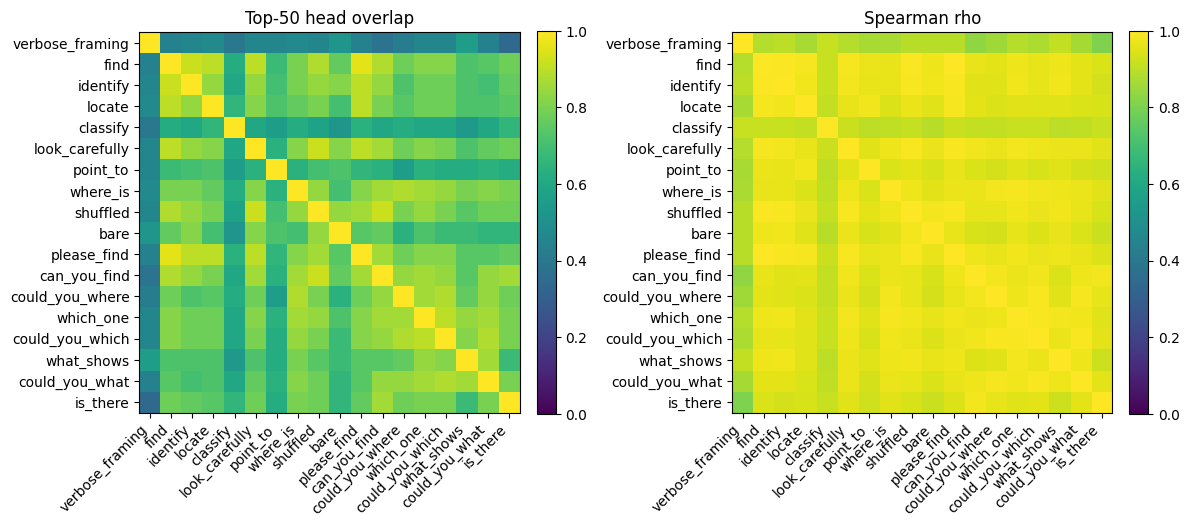


        phrasing        mean      median         std         max
 verbose_framing     0.04687     0.01462     0.08169     0.69478
            find     0.02608     0.01343     0.03573     0.29756
        identify     0.02544     0.01260     0.03420     0.28372
          locate     0.02518     0.01270     0.03500     0.29723
        classify     0.02311     0.01060     0.03556     0.37573
  look_carefully     0.02494     0.01300     0.03293     0.30249
        point_to     0.02238     0.01027     0.03448     0.45041
        where_is     0.02445     0.01195     0.03468     0.26207
        shuffled     0.02600     0.01386     0.03455     0.33638
            bare     0.02980     0.01492     0.03953     0.34190
     please_find     0.02545     0.01287     0.03571     0.30428
    can_you_find     0.02124     0.00995     0.03025     0.22796
 could_you_where     0.02160     0.01005     0.03066     0.22130
       which_one     0.02339     0.01152     0.03380     0.29473
 could_you_which     0.0

In [4]:
tags = list(PROMPT_FNS.keys())
K = 50
print(f"=== Pairwise top-{K} overlap / Spearman rho across phrasings ===")
overlap_matrix = np.zeros((len(tags), len(tags)))
rho_matrix = np.zeros((len(tags), len(tags)))
for i, a in enumerate(tags):
    top_a = set((r["layer"], r["head"]) for r in vis_head_ranked[a][:K])
    for j, b in enumerate(tags):
        top_b = set((r["layer"], r["head"]) for r in vis_head_ranked[b][:K])
        overlap_matrix[i, j] = len(top_a & top_b) / K
        rho_matrix[i, j] = stats.spearmanr(vis_head_scores[a].reshape(-1), vis_head_scores[b].reshape(-1)).correlation

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, mat, title in ((axes[0], overlap_matrix, f"Top-{K} head overlap"), (axes[1], rho_matrix, "Spearman rho")):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(tags))); ax.set_xticklabels(tags, rotation=45, ha="right")
    ax.set_yticks(range(len(tags))); ax.set_yticklabels(tags)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
save_path = outputs.figures_dir / "vis_head_score_phrasing_matrix.pdf"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

print(f"\n{'phrasing':>16s}  {'mean':>10s}  {'median':>10s}  {'std':>10s}  {'max':>10s}")
for tag in tags:
    scores_flat = vis_head_scores[tag].reshape(-1)
    print(f"{tag:>16s}  {scores_flat.mean():10.5f}  {np.median(scores_flat):10.5f}  "
          f"{scores_flat.std():10.5f}  {scores_flat.max():10.5f}")


### Normalized (relative-to-own-max) Vis-Head scores

Raw score magnitude isn't directly comparable across phrasings — `verbose_framing`'s
scores run ~1.6-1.8x higher overall (more general attention engagement, not
necessarily better targeting; matches the same pattern found for base-vs-instruct
concentration and for the ImageNet filler-dilution experiments elsewhere in this
project). Dividing out target-region size (this project's usual "normalized" score)
doesn't help *here* specifically, since every phrasing uses the same fixed 2x2 grid —
all cells are the same size, so that normalization is just a constant rescale that
changes nothing relative. What actually matters for comparing phrasings is each
head's score **relative to that phrasing's own top head** — a head scoring 1.0 is
that phrasing's strongest Vis-Head; 0.5 means half as much attention on target as the
strongest one, regardless of how phrasings differ in overall scale.

        phrasing        mean      median         std         max
 verbose_framing     0.06746     0.02104     0.11758     1.00000
            find     0.08763     0.04512     0.12007     1.00000
        identify     0.08966     0.04440     0.12053     1.00000
          locate     0.08471     0.04273     0.11774     1.00000
        classify     0.06150     0.02821     0.09464     1.00000
  look_carefully     0.08245     0.04299     0.10888     1.00000
        point_to     0.04969     0.02280     0.07654     1.00000
        where_is     0.09328     0.04561     0.13235     1.00000
        shuffled     0.07730     0.04121     0.10270     1.00000
            bare     0.08715     0.04362     0.11561     1.00000
     please_find     0.08363     0.04229     0.11735     1.00000
    can_you_find     0.09318     0.04366     0.13269     1.00000
 could_you_where     0.09760     0.04542     0.13856     1.00000
       which_one     0.07936     0.03908     0.11467     1.00000
 could_you_which     0.07

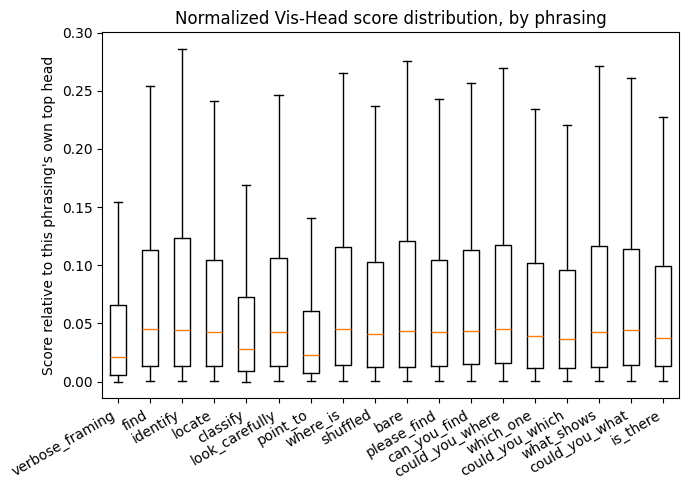

In [5]:
print(f"{'phrasing':>16s}  {'mean':>10s}  {'median':>10s}  {'std':>10s}  {'max':>10s}")
normalized_scores = {}
for tag in tags:
    scores_flat = vis_head_scores[tag].reshape(-1)
    norm_flat = scores_flat / max(scores_flat.max(), 1e-12)   # relative to this phrasing's own top head
    normalized_scores[tag] = norm_flat
    print(f"{tag:>16s}  {norm_flat.mean():10.5f}  {np.median(norm_flat):10.5f}  "
          f"{norm_flat.std():10.5f}  {norm_flat.max():10.5f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([normalized_scores[t] for t in tags], tick_labels=tags, showfliers=False)
ax.set_ylabel("Score relative to this phrasing's own top head")
ax.set_title("Normalized Vis-Head score distribution, by phrasing")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(outputs.figures_dir / "vis_head_score_normalized_by_phrasing.pdf", bbox_inches="tight")
plt.show()


## Part 2 — Causal pointing-game accuracy, per phrasing

Three conditions on the same 600 samples:

- **baseline** — the neutral MCQ prompt, no location info, no intervention. Shared
  across phrasings (doesn't depend on which heads were discovered).
- **location-cue** — the model is told exactly where the target is via a **bounding
  box in pixel coordinates**, no attention intervention. Deliberately simple wording
  (a single short sentence, no counting/row-column explanation) so the model isn't
  confused by the instruction itself, only tested on whether it can use the location
  info. Also shared across phrasings — it's a language-only baseline, independent of
  Vis-Head discovery.
- **steered** — the neutral MCQ prompt (no location text), but the **phrasing's own
  top-K Vis-Heads** (from Part 1) are forced onto the target cell. This is the only
  condition that varies by phrasing.

Computing baseline and location-cue once (not once per phrasing) since neither uses
the discovered heads — this cuts total generations roughly in half versus recomputing
them per phrasing.

In [6]:
def build_mcq_sample(rng: np.random.RandomState) -> dict:
    grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                        class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
    target_cell = int(rng.randint(N_CELLS))
    correct_name = grid.cell_names[target_cell]
    other_names = [n for i, n in enumerate(grid.cell_names) if i != target_cell]
    n_distractors = min(N_OPTIONS - 1, len(other_names))
    distractor_idx = rng.choice(len(other_names), size=n_distractors, replace=False)
    distractors = [other_names[i] for i in distractor_idx]
    options = [correct_name] + distractors
    order = rng.permutation(len(options))
    options = [options[i] for i in order]
    correct_letter = OPTION_LETTERS[int(np.where(order == 0)[0][0])]
    option_lines = "  ".join(f"{letter}) {name}" for letter, name in zip(OPTION_LETTERS[:len(options)], options))
    prompt = f"Which of the following is shown in this image? {option_lines}. Answer with only the letter."
    location_prompt = mcq_prompt(target_cell + 1, ROWS, COLS, options, OPTION_LETTERS[:len(options)])
    return {"grid": grid, "target_cell": target_cell, "options": options, "correct_letter": correct_letter,
            "prompt": prompt, "location_prompt": location_prompt}


def get_letter_token_ids(tokenizer, letters):
    """Map each option letter to the single-token ids that could represent it as
    the model's very next generated token (bare and leading-space variants)."""
    ids = {}
    for letter in letters:
        candidates = set()
        for cand in (letter, f" {letter}"):
            enc = tokenizer.encode(cand, add_special_tokens=False)
            if len(enc) == 1:
                candidates.add(enc[0])
        if not candidates:
            raise ValueError(f"No single-token encoding found for letter {letter!r}")
        ids[letter] = sorted(candidates)
    return ids


letter_token_ids = get_letter_token_ids(processor.tokenizer, OPTION_LETTERS)


def run_mcq(sample: dict, heads_by_layer: dict | None, prompt_key: str = "prompt") -> dict:
    """One forward pass (no multi-token generation needed): reads next-token
    logits at the final prompt position, restricted to the option letters, for a
    real probability vector (accuracy/F1/AUC); also returns the last transformer
    layer's hidden state at that position for a downstream linear probe."""
    inputs = prepare_inputs(processor, sample["grid"].grid, sample[prompt_key], DEVICE)
    prompt_length = int(inputs["input_ids"].shape[1])

    handles = []
    if heads_by_layer is not None:
        img_start, img_end = find_image_token_range(inputs, processor)
        region_ids, _ = assign_grid_cells_to_tokens(
            image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
        positions = region_positions_from_ids(img_start=img_start, region_ids=region_ids, n_regions=N_CELLS)
        target_positions = positions[sample["target_cell"]]
        other_positions = [p for i in range(N_CELLS) if i != sample["target_cell"] for p in positions[i]]
        suppress_positions, boost_positions, pad = intervention_positions(
            mode="boost_suppress", target_positions=target_positions, other_image_positions=other_positions,
            img_start=img_start, img_end=img_end, prompt_length=prompt_length)
        hook_by_layer = {
            layer_idx: make_static_attention_mask_hook(
                head_indices=heads, suppress_positions=suppress_positions, boost_positions=boost_positions,
                n_query_heads=n_heads, device=DEVICE, decode_only=False, pad_with_suppress=pad)
            for layer_idx, heads in heads_by_layer.items()
        }
        handles = register_mask_hooks(model, hook_by_layer)

    try:
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True, use_cache=False)
        next_logits = out.logits[0, -1, :].float()
        hidden = out.hidden_states[-1][0, -1, :].float().cpu().numpy()
    finally:
        remove_handles(handles)

    valid_letters = OPTION_LETTERS[: len(sample["options"])]
    letter_logits = [next_logits[letter_token_ids[l]].max().item() for l in valid_letters]
    probs = torch.softmax(torch.tensor(letter_logits), dim=0).numpy()
    padded_probs = np.zeros(N_OPTIONS)
    padded_probs[: len(probs)] = probs
    predicted = valid_letters[int(np.argmax(probs))]
    return {"predicted": predicted, "correct": predicted == sample["correct_letter"],
            "probs": padded_probs, "hidden": hidden, "correct_letter": sample["correct_letter"]}


mcq_rng = np.random.RandomState(SEED + 555)
mcq_samples = [build_mcq_sample(mcq_rng) for _ in range(N_MCQ_SAMPLES)]

# baseline and location-cue are language-only (no head intervention) -> shared across
# all phrasings, computed once instead of once per phrasing.
shared_baseline_res, shared_location_res = [], []
for sample in tqdm(mcq_samples, desc="MCQ [baseline + location-cue]", leave=False):
    shared_baseline_res.append(run_mcq(sample, None, prompt_key="prompt"))
    shared_location_res.append(run_mcq(sample, None, prompt_key="location_prompt"))
b_acc = np.mean([r["correct"] for r in shared_baseline_res])
l_acc = np.mean([r["correct"] for r in shared_location_res])
print(f"  [shared]  baseline={b_acc:.3f}  location-cue={l_acc:.3f}")

mcq_results = {}
for tag in tags:
    heads_by_layer = group_heads_by_layer([(r["layer"], r["head"]) for r in vis_head_ranked[tag][:TOP_K_HEADS]])
    steered_res = []
    for sample in tqdm(mcq_samples, desc=f"MCQ [{tag}] steered", leave=False):
        steered_res.append(run_mcq(sample, heads_by_layer, prompt_key="prompt"))
    mcq_results[tag] = {"baseline": shared_baseline_res, "location_cue": shared_location_res, "steered": steered_res}
    s_acc = np.mean([r["correct"] for r in steered_res])
    print(f"  [{tag:>10s}] steered={s_acc:.3f}")

MCQ [baseline + location-cue]:   0%|          | 0/300 [00:00<?, ?it/s]

  [shared]  baseline=0.247  location-cue=0.987


MCQ [verbose_framing] steered:   0%|          | 0/300 [00:00<?, ?it/s]

  [verbose_framing] steered=0.593


MCQ [find] steered:   0%|          | 0/300 [00:00<?, ?it/s]

...

  [what_shows] steered=0.707


MCQ [could_you_what] steered:   0%|          | 0/300 [00:00<?, ?it/s]

  [could_you_what] steered=0.673


MCQ [is_there] steered:   0%|          | 0/300 [00:00<?, ?it/s]

  [  is_there] steered=0.457


In [7]:
def mcnemar_p(cond_a, cond_b):
    b = sum(1 for a, c in zip(cond_a, cond_b) if not a["correct"] and c["correct"])
    c = sum(1 for a, c in zip(cond_a, cond_b) if a["correct"] and not c["correct"])
    n_discordant = b + c
    if n_discordant == 0:
        return float("nan")
    stat = (abs(b - c) - 1) ** 2 / n_discordant
    return float(stats.chi2.sf(stat, df=1))


def gen_metrics(results_list):
    """accuracy / macro-F1 / macro one-vs-rest AUC from the letter-logit probabilities."""
    y_true = [r["correct_letter"] for r in results_list]
    y_pred = [r["predicted"] for r in results_list]
    probs = np.stack([r["probs"] for r in results_list])
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, labels=OPTION_LETTERS, average="macro")
    y_true_bin = label_binarize(y_true, classes=OPTION_LETTERS)
    try:
        auc = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        auc = float("nan")
    return {"accuracy": acc, "f1": f1, "auc": auc}


def fit_and_eval_probe(results_list, seed=SEED):
    """Multinomial logistic-regression probe on the final-layer hidden states ->
    accuracy / macro-F1 / macro one-vs-rest AUC on a held-out split."""
    X = np.stack([r["hidden"] for r in results_list])
    y = np.array([r["correct_letter"] for r in results_list])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, labels=clf.classes_, average="macro")
    y_proba = clf.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=clf.classes_)
    try:
        auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
    except ValueError:
        auc = float("nan")
    return {"accuracy": acc, "f1": f1, "auc": auc}


chance_rate = 1.0 / N_OPTIONS
b_ci = bootstrap_ci([r["correct"] for r in shared_baseline_res])
l_ci = bootstrap_ci([r["correct"] for r in shared_location_res])
p_loc_vs_base = mcnemar_p(shared_baseline_res, shared_location_res)
b_acc, b_lo, b_hi, b_n = b_ci["accuracy"], b_ci["ci_low"], b_ci["ci_high"], b_ci["n"]
l_acc, l_lo, l_hi, l_n = l_ci["accuracy"], l_ci["ci_low"], l_ci["ci_high"], l_ci["n"]
print(f"Chance rate: {chance_rate:.3f}")
print(f"Shared baseline    : {b_acc:.3f}  [{b_lo:.3f}, {b_hi:.3f}]  (n={b_n})")
print(f"Shared location-cue: {l_acc:.3f}  [{l_lo:.3f}, {l_hi:.3f}]  (n={l_n})  vs baseline p={p_loc_vs_base:.3e}")

base_gen = gen_metrics(shared_baseline_res)
loc_gen = gen_metrics(shared_location_res)
base_probe = fit_and_eval_probe(shared_baseline_res)
loc_probe = fit_and_eval_probe(shared_location_res)

bg_acc, bg_f1, bg_auc = base_gen["accuracy"], base_gen["f1"], base_gen["auc"]
bp_acc, bp_f1, bp_auc = base_probe["accuracy"], base_probe["f1"], base_probe["auc"]
lg_acc, lg_f1, lg_auc = loc_gen["accuracy"], loc_gen["f1"], loc_gen["auc"]
lp_acc, lp_f1, lp_auc = loc_probe["accuracy"], loc_probe["f1"], loc_probe["auc"]
print(f"\nShared baseline    gen: acc={bg_acc:.3f} f1={bg_f1:.3f} auc={bg_auc:.3f}  "
      f"probe: acc={bp_acc:.3f} f1={bp_f1:.3f} auc={bp_auc:.3f}")
print(f"Shared location-cue gen: acc={lg_acc:.3f} f1={lg_f1:.3f} auc={lg_auc:.3f}  "
      f"probe: acc={lp_acc:.3f} f1={lp_f1:.3f} auc={lp_auc:.3f}")
print()

col_names = ["phrasing", "steered", "f1", "auc", "probe_acc", "probe_f1", "probe_auc", "p(s,b)", "p(s,l)"]
col_widths = [16, 8, 6, 6, 10, 9, 10, 10, 10]
header = "  ".join(f"{name:>{w}s}" for name, w in zip(col_names, col_widths))
print(header)
summary_rows = []
for tag in tags:
    steered = mcq_results[tag]["steered"]
    s_ci = bootstrap_ci([r["correct"] for r in steered])
    s_acc, s_lo, s_hi = s_ci["accuracy"], s_ci["ci_low"], s_ci["ci_high"]
    s_gen = gen_metrics(steered)
    s_probe = fit_and_eval_probe(steered)
    sg_f1, sg_auc = s_gen["f1"], s_gen["auc"]
    sp_acc, sp_f1, sp_auc = s_probe["accuracy"], s_probe["f1"], s_probe["auc"]
    p_steer_vs_base = mcnemar_p(shared_baseline_res, steered)
    p_steer_vs_loc = mcnemar_p(shared_location_res, steered)
    row_vals = [tag, f"{s_acc:.3f}", f"{sg_f1:.3f}", f"{sg_auc:.3f}",
                f"{sp_acc:.3f}", f"{sp_f1:.3f}", f"{sp_auc:.3f}",
                f"{p_steer_vs_base:.3e}", f"{p_steer_vs_loc:.3e}"]
    print("  ".join(f"{v:>{w}s}" for v, w in zip(row_vals, col_widths)))
    summary_rows.append({
        "phrasing": tag, "baseline_acc": b_acc, "location_cue_acc": l_acc, "steered_acc": s_acc,
        "steered_f1": sg_f1, "steered_auc": sg_auc,
        "steered_probe_acc": sp_acc, "steered_probe_f1": sp_f1, "steered_probe_auc": sp_auc,
        "p_steer_vs_base": p_steer_vs_base, "p_steer_vs_loc": p_steer_vs_loc,
        "vis_head_mean_score": float(vis_head_scores[tag].mean()),
    })

dump_json(outputs.logs_dir / "prompt_phrasing_sweep_summary.json", summary_rows)

Chance rate: 0.250
Shared baseline    : 0.247  [0.197, 0.297]  (n=300)
Shared location-cue: 0.987  [0.973, 0.997]  (n=300)  vs baseline p=9.024e-50



Shared baseline    gen: acc=0.247 f1=0.244 auc=0.489  probe: acc=0.244 f1=0.220 auc=0.488
Shared location-cue gen: acc=0.987 f1=0.987 auc=1.000  probe: acc=0.989 f1=0.990 auc=1.000

        phrasing   steered      f1     auc   probe_acc   probe_f1   probe_auc      p(s,b)      p(s,l)


 verbose_framing     0.593   0.588   0.799       0.600      0.592       0.841   5.070e-22   4.733e-27


            find     0.653   0.649   0.840       0.700      0.708       0.890   6.171e-26   4.163e-23


        identify     0.653   0.649   0.840       0.700      0.708       0.890   6.171e-26   4.163e-23


...

 could_you_which     0.567   0.564   0.753       0.633      0.634       0.852   2.099e-21   8.391e-29


      what_shows     0.707   0.703   0.867       0.722      0.723       0.909   3.452e-30   1.353e-19


  could_you_what     0.673   0.670   0.825       0.644      0.650       0.869   8.136e-29   8.621e-22


        is_there     0.457   0.454   0.692       0.522      0.513       0.736   8.118e-13   5.102e-36


PosixPath('/mnt/abka03/Projects/vis-head/logs/prompt_phrasing_sweep/prompt_phrasing_sweep_summary.json')

## Part 3 — Vis-Head score vs. causal accuracy, side by side

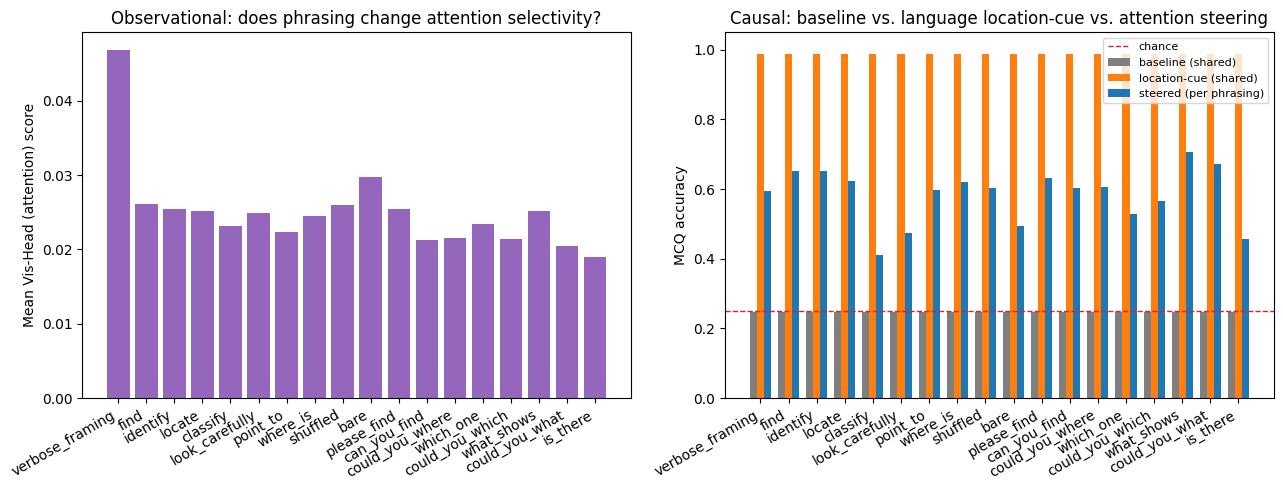

Read the two panels together:
- If the LEFT panel varies a lot across phrasings but steered accuracy on the RIGHT
  doesn't track it, attention identity/magnitude and causal effect have dissociated
  again -- consistent with every other comparison in this project.
- The shared baseline and location-cue bars are constant across phrasings by
  construction (they never use the discovered heads) -- they're the reference line
  each phrasing's steered bar should be compared against, not to each other.
- If steered beats location-cue, forcing attention is a stronger causal lever than
  telling the model the answer's location in words, even with a simple, unambiguous
  bounding-box instruction.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(tags))

mean_scores = [vis_head_scores[t].mean() for t in tags]
axes[0].bar(x, mean_scores, color="tab:purple")
axes[0].set_xticks(x); axes[0].set_xticklabels(tags, rotation=30, ha="right")
axes[0].set_ylabel("Mean Vis-Head (attention) score")
axes[0].set_title("Observational: does phrasing change attention selectivity?")

width = 0.25
baseline_acc = np.mean([r["correct"] for r in shared_baseline_res])
location_acc = np.mean([r["correct"] for r in shared_location_res])
steered_accs = [np.mean([r["correct"] for r in mcq_results[t]["steered"]]) for t in tags]
axes[1].bar(x - width, [baseline_acc] * len(tags), width, label="baseline (shared)", color="tab:gray")
axes[1].bar(x, [location_acc] * len(tags), width, label="location-cue (shared)", color="tab:orange")
axes[1].bar(x + width, steered_accs, width, label="steered (per phrasing)", color="tab:blue")
axes[1].axhline(chance_rate, color="tab:red", linestyle="--", linewidth=1, label="chance")
axes[1].set_xticks(x); axes[1].set_xticklabels(tags, rotation=30, ha="right")
axes[1].set_ylabel("MCQ accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Causal: baseline vs. language location-cue vs. attention steering")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(outputs.figures_dir / "vis_head_score_vs_causal_accuracy.pdf", bbox_inches="tight")
plt.show()

print("Read the two panels together:")
print("- If the LEFT panel varies a lot across phrasings but steered accuracy on the RIGHT")
print("  doesn't track it, attention identity/magnitude and causal effect have dissociated")
print("  again -- consistent with every other comparison in this project.")
print("- The shared baseline and location-cue bars are constant across phrasings by")
print("  construction (they never use the discovered heads) -- they're the reference line")
print("  each phrasing's steered bar should be compared against, not to each other.")
print("- If steered beats location-cue, forcing attention is a stronger causal lever than")
print("  telling the model the answer's location in words, even with a simple, unambiguous")
print("  bounding-box instruction.")
